# 🗑️ YOLOv8x Fine-Tuning — NEAT NOW Waste Detection
> **9-class Pakistani garbage detection | Google Colab | Roboflow | Max Accuracy**

---

## Quick Start
1. `Runtime → Change runtime type → T4 GPU` (A100 even better)
2. Edit **Cell 1**: set `RF_API_KEY`, `RF_WORKSPACE`, `RF_PROJECT`, `RF_VERSION`
3. `Runtime → Run all` — everything else is automatic

## Notebook Structure
| Cell | Purpose |
|------|---------|
| 1 | Mount Drive · **Roboflow download** · dataset extraction |
| 2 | GPU check + CUDA compatibility |
| 3 | Install dependencies |
| 4 | Imports & reproducibility |
| 5 | Dataset paths & configuration |
| 6 | Helper functions |
| 7 | Dataset inspection & class analysis |
| 8 | Sample image visualisation |
| 9 | Generate `data.yaml` |
| 10 | **YOLOv8x** hyperparameters (max-accuracy config) |
| 11 | Training |
| 12 | Evaluate best checkpoint |
| 13 | Training curve visualisations |
| 14 | Inference on test images |
| 15 | ONNX export |
| 16 | Final summary & save to Drive |


In [1]:
# ============================================================================
# CELL 1 — Mount Google Drive + Roboflow Dataset Download
# ============================================================================
# ┌──────────────────────────────────────────────────────────────────────────┐
# │  EDIT THESE FOUR VALUES — everything else is automatic                  │
RF_API_KEY   = "YOUR_ROBOFLOW_API_KEY"   # roboflow.com → Settings → API
RF_WORKSPACE = "your-workspace-slug"     # e.g.  "fyp-gojku"
RF_PROJECT   = "your-project-slug"       # e.g.  "asian-waste-detection-dihfa-m9t9o-hqccl"
RF_VERSION   = 1                         # dataset version number (int)
# └──────────────────────────────────────────────────────────────────────────┘

import os, subprocess, shutil, sys
from pathlib import Path
from google.colab import drive

# ── Mount Drive ───────────────────────────────────────────────────────────────
drive.mount("/content/drive", force_remount=False)
print("[OK] Google Drive mounted")

DRIVE_ROOT  = Path("/content/drive/MyDrive/FYP")
OUTPUT_DIR  = DRIVE_ROOT / "outputs/roboflow-run"
MODELS_DIR  = DRIVE_ROOT / "models/roboflow-run"
WORKING_DIR = Path("/content")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"[OK] Output dir : {OUTPUT_DIR}")

# ── Install Roboflow SDK ──────────────────────────────────────────────────────
print("Installing roboflow SDK...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "roboflow",
                "--disable-pip-version-check"], check=True)
print("[OK] roboflow installed")

# ── Helpers ───────────────────────────────────────────────────────────────────
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def _count_images(directory):
    p = Path(directory)
    if not p.exists():
        return 0
    return sum(1 for f in p.iterdir() if f.suffix.lower() in IMG_EXTS)

def _is_valid_yolo_root(root, min_images=10):
    """
    True if root contains:
      train/images/  with >= min_images files
      valid/images/ or val/images/  with >= 1 file
    """
    root = Path(root)
    hits = list(root.rglob("train/images"))
    if not hits:
        return False
    train_img_dir = hits[0]
    if _count_images(train_img_dir) < min_images:
        return False
    base = train_img_dir.parent.parent          # the YOLO root dir
    val_dir = (base / "valid" / "images" if (base / "valid").exists()
               else base / "val" / "images")
    return _count_images(val_dir) >= 1

def _find_yolo_root(search_path):
    """
    Return the first directory under search_path that passes
    _is_valid_yolo_root(), checking shallowest dirs first.
    Returns None if nothing found.
    """
    search_path = Path(search_path)
    if not search_path.exists():
        return None
    # Check root itself
    if _is_valid_yolo_root(search_path):
        return search_path
    # Immediate children first (avoids walking huge trees unnecessarily)
    for child in sorted(search_path.iterdir()):
        if child.is_dir() and _is_valid_yolo_root(child):
            return child
    # Full deep scan as last resort
    for hit in sorted(search_path.rglob("train/images")):
        candidate = hit.parent.parent
        if _is_valid_yolo_root(candidate):
            return candidate
    return None

# ── Download from Roboflow ────────────────────────────────────────────────────
if not RF_API_KEY or RF_API_KEY == "YOUR_ROBOFLOW_API_KEY":
    raise ValueError(
        "RF_API_KEY is not set!\n"
        "Paste your key into RF_API_KEY at the top of this cell.\n"
        "Get it at: https://app.roboflow.com → Settings → Roboflow API"
    )

DL_DIR = Path("/content/rf_dataset")
if DL_DIR.exists():
    shutil.rmtree(DL_DIR)
DL_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nDownloading {RF_WORKSPACE}/{RF_PROJECT} v{RF_VERSION} ...")
from roboflow import Roboflow

rf      = Roboflow(api_key=RF_API_KEY)
project = rf.workspace(RF_WORKSPACE).project(RF_PROJECT)
dataset = project.version(RF_VERSION).download("yolov8", location=str(DL_DIR), overwrite=True)

# ── Locate actual files ───────────────────────────────────────────────────────
# IMPORTANT: Roboflow SDK may ignore the `location` parameter and place files at
# dataset.location instead. We must check dataset.location first, then fall back
# to searching DL_DIR and the broader /content/ tree.
search_paths = []
if hasattr(dataset, "location") and dataset.location:
    search_paths.append(Path(dataset.location))   # SDK's actual download path
search_paths.append(DL_DIR)                       # where we asked it to go
search_paths.append(Path("/content"))             # broad fallback

DATASET_ROOT = None
for sp in search_paths:
    root = _find_yolo_root(sp)
    if root is not None:
        DATASET_ROOT = root
        print(f"[OK] Dataset found at : {DATASET_ROOT}  (searched: {sp})")
        break

if DATASET_ROOT is None:
    # Print full tree so the user can see what actually downloaded
    print("\n[ERROR] No valid YOLO dataset found. Full /content/ tree:")
    for dirpath, dirnames, filenames in os.walk("/content"):
        # Skip Drive, proc, sys dirs
        dirnames[:] = [d for d in dirnames
                       if d not in ("drive", "proc", "sys", "dev", ".config")]
        depth  = dirpath.count(os.sep) - 1
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath)}/")
        if depth < 5:
            for fname in sorted(filenames)[:4]:
                print(f"{indent}  {fname}")
    raise FileNotFoundError(
        "\nRoboflow download succeeded but no train/images found anywhere.\n"
        "Likely cause: RF_VERSION is wrong or the project has no YOLOv8 export.\n"
        "Fix: open your project on roboflow.com, click Export → YOLOv8 → Generate."
    )

# ── Final summary ─────────────────────────────────────────────────────────────
train_dir = next(DATASET_ROOT.rglob("train/images"))
val_candidates = (list(DATASET_ROOT.rglob("valid/images")) or
                  list(DATASET_ROOT.rglob("val/images")))
val_dir = val_candidates[0] if val_candidates else None

n_train = _count_images(train_dir)
n_val   = _count_images(val_dir) if val_dir else 0

print(f"[OK] Train images : {n_train:,}")
print(f"[OK] Val   images : {n_val:,}")
print("=" * 70)


Mounted at /content/drive
[OK] Google Drive mounted
Extracting /content/drive/MyDrive/FYP/Datasets/24-March/Asian-Waste-Detection.v25i.yolov8.zip ...
[OK] Extracted to /content/dataset
[OK] Dataset root : /content/dataset
[OK] Training images found: 6,888


In [2]:
# ============================================================================
# CELL 2 — GPU Check + CUDA Compatibility  (Colab T4 / A100 / V100 aware)
# ============================================================================
import subprocess, sys, torch

SEP = "=" * 70
print("\n" + SEP + "\nGPU & RUNTIME CHECK\n" + SEP)

CUDA_AVAILABLE        = torch.cuda.is_available()
NEEDS_TORCH_REINSTALL = False
DEVICE     = "cpu"
GPU_NAME   = "CPU"
VRAM_GB    = 0.0
BATCH_SIZE = 8
IMG_SIZE   = 640
WORKERS    = 2
HALF       = False

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {CUDA_AVAILABLE}")

if CUDA_AVAILABLE:
    DEVICE = "cuda"
    props  = torch.cuda.get_device_properties(0)
    GPU_NAME  = props.name
    VRAM_GB   = props.total_memory / 1024**3
    CC_MAJOR  = props.major
    CC_MINOR  = props.minor

    print(f"\nGPU  : {GPU_NAME}")
    print(f"VRAM : {VRAM_GB:.1f} GB")
    print(f"Compute Capability : {CC_MAJOR}.{CC_MINOR}")

    cuda_kernel_ok = False
    try:
        _ = torch.zeros(1, device="cuda") + 1
        cuda_kernel_ok = True
    except Exception:
        pass
    print("[OK] CUDA kernel smoke-test passed" if cuda_kernel_ok else "[WARN] CUDA smoke-test failed")

    # ── GPU tier → recommended batch + imgsz ──────────────────────────────────
    if VRAM_GB >= 38:           # A100 40GB
        BATCH_SIZE, IMG_SIZE, WORKERS, tier = 32, 640, 4, "A100 (>=38 GB)"
        HALF = True
    elif VRAM_GB >= 22:         # A100 24GB / V100 32GB
        BATCH_SIZE, IMG_SIZE, WORKERS, tier = 16, 640, 4, "High-end (22-38 GB)"
        HALF = True
    elif VRAM_GB >= 14:         # T4 (15.7 GB)  ← standard Colab free
        BATCH_SIZE, IMG_SIZE, WORKERS, tier = 16, 640, 2, "T4 (14-22 GB)"
        HALF = True
    elif VRAM_GB >= 10:
        BATCH_SIZE, IMG_SIZE, WORKERS, tier = 8,  640, 2, "Mid-range (10-14 GB)"
        HALF = True
    else:
        BATCH_SIZE, IMG_SIZE, WORKERS, tier = 4,  416, 2, "Low VRAM (<10 GB)"

    # Pascal (P100 = sm_60) check
    IS_PASCAL = (CC_MAJOR == 6)
    if IS_PASCAL:
        print("\n[INFO] Pascal GPU detected — BF16 unsupported; will use FP16.")
        NEEDS_TORCH_REINSTALL = True   # may need CUDA 11.x build

    print(f"\nTier       : {tier}")
else:
    print("\n[WARN] No GPU — training will be extremely slow.")

print(f"Batch size : {BATCH_SIZE}")
print(f"Img size   : {IMG_SIZE}")
print(f"Workers    : {WORKERS}")
print(f"Half (FP16): {HALF}")
print(SEP)



GPU & RUNTIME CHECK
PyTorch      : 2.10.0+cu128
CUDA         : available
GPU          : Tesla T4
VRAM         : 14.6 GB
Compute cap  : 7.5
[OK] CUDA kernel compatibility confirmed
Tier         : T4 (15 GB)

Batch size   : 16
Image size   : 640px
Workers      : 4


In [3]:
# ============================================================================
# CELL 3 — Install Dependencies + Auto-fix PyTorch/CUDA Incompatibility
# FIX: version-fallback chain for P100 (sm_60) — tries 2.3.1 down to 2.2.0
# FIX: subprocess used instead of shell magic so errors are caught properly
# ============================================================================

import subprocess, sys, importlib

def _run(cmd: str) -> int:
    """Run shell command, stream output, return exit code."""
    proc = subprocess.Popen(cmd, shell=True,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()
    return proc.returncode

# ── Step 1: fix PyTorch if sm_60 incompatibility detected (Cell 2) ───────────
if "NEEDS_TORCH_REINSTALL" in dir() and NEEDS_TORCH_REINSTALL:
    CANDIDATES = [("2.3.1","0.18.1"), ("2.3.0","0.18.0"),
                  ("2.2.2","0.17.2"), ("2.2.1","0.17.1"), ("2.2.0","0.17.0")]
    installed = False
    for tv, tvv in CANDIDATES:
        print(f"Trying torch=={tv}+cu118 ...")
        rc = _run(f"{sys.executable} -m pip install -q torch=={tv}+cu118 "
                  f"torchvision=={tvv}+cu118 "
                  f"--index-url https://download.pytorch.org/whl/cu118")
        if rc == 0:
            print(f"[OK] torch=={tv}+cu118 installed")
            installed = True; break
        print(f"[skip] {tv} not available")

    if not installed:
        raise RuntimeError("Could not install compatible PyTorch. "
                           "Try manually: !pip install torch==2.3.1+cu118 "
                           "--index-url https://download.pytorch.org/whl/cu118")

    print("\n[RESTART] Restarting kernel to load new PyTorch...")
    try:
        import IPython; IPython.get_ipython().kernel.do_shutdown(restart=True)
    except Exception:
        print("[WARN] Auto-restart failed — please restart kernel manually.")
    raise SystemExit(0)
else:
    print("[OK] PyTorch is compatible — no reinstall needed.")

# ── Step 2: install / upgrade all other packages ──────────────────────────────
print("\nInstalling dependencies...")
rc = _run(f"{sys.executable} -m pip install -q -U "
          "ultralytics albumentations opencv-python-headless "
          "matplotlib seaborn pandas scikit-learn tqdm onnx onnxruntime")
if rc != 0:
    print("[WARN] Some packages may not have installed correctly.")

# ── Step 3: verify ────────────────────────────────────────────────────────────
required = {"ultralytics":"ultralytics","cv2":"opencv-python-headless",
            "albumentations":"albumentations","onnx":"onnx"}
print()
all_ok = True
for mod, pkg in required.items():
    try:
        m = importlib.import_module(mod)
        print(f"  [OK] {pkg:<28} {getattr(m,'__version__','?')}")
    except ImportError:
        print(f"  [FAIL] {pkg}"); all_ok = False

import torch
print(f"  [OK] torch                       {torch.__version__}")
try:
    torch.zeros(1, device="cuda") + 1
    print(f"  [OK] CUDA smoke-test             passed")
except Exception as e:
    print(f"  [WARN] CUDA smoke-test           {e}"); all_ok = False

print("\n[OK] All dependencies ready." if all_ok else "\n[WARN] Fix issues above before training.")


[OK] PyTorch is compatible — no reinstall needed.

Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 31.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires

In [4]:
# ============================================================================
# CELL 4 — Imports & Reproducibility
# FIX: cudnn.benchmark left True (benchmark=False was unnecessarily slowing
#      training — deterministic + benchmark=True is safe for fixed input sizes)
# ============================================================================

import random, warnings, json, csv, logging, shutil, time
from datetime import datetime
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    # benchmark=True is fine with fixed imgsz — it picks the fastest algorithm
    torch.backends.cudnn.benchmark = True

# ── Plotting defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "figure.facecolor": "white", "axes.facecolor": "white",
})
sns.set_theme(style="whitegrid", palette="muted")

# ── Logger ────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] %(levelname)-8s %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("waste_det")

print("[OK] Imports complete")
print(f"[OK] Seeds fixed (seed={SEED})")
print("=" * 70)


[OK] Imports complete
[OK] Seeds fixed (seed=42)


In [5]:
# ============================================================================
# CELL 5 — Dataset Configuration
# FIX: handles both "valid/" and "val/" folder names
# FIX: raises RuntimeError instead of sys.exit() (keeps kernel alive)
# ============================================================================

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASS_NAMES = [
    "Animal Waste", "Construction Waste", "Garbage Bag", "Glass", "Metal",
    "Organic", "Paper", "Plastic", "waste",
]
NUM_CLASSES = len(CLASS_NAMES)

# ── Resolve split paths (valid/ or val/) ──────────────────────────────────────
TRAIN_IMAGES = DATASET_ROOT / "train"  / "images"
TRAIN_LABELS = DATASET_ROOT / "train"  / "labels"

_val_name    = "valid" if (DATASET_ROOT / "valid").exists() else "val"
VAL_IMAGES   = DATASET_ROOT / _val_name / "images"
VAL_LABELS   = DATASET_ROOT / _val_name / "labels"

TEST_IMAGES  = DATASET_ROOT / "test"   / "images"
TEST_LABELS  = DATASET_ROOT / "test"   / "labels"

# ── Verify required splits ────────────────────────────────────────────────────
print("Dataset paths:")
for label, p in [
    ("Train images", TRAIN_IMAGES), ("Train labels", TRAIN_LABELS),
    ("Val   images", VAL_IMAGES),   ("Val   labels", VAL_LABELS),
    ("Test  images", TEST_IMAGES),
]:
    status = "[OK]" if p.exists() else "[MISSING]"
    n = sum(1 for f in p.glob("*") if f.suffix.lower() in IMG_EXTS) if p.exists() else 0
    suffix = f"  [{n:,} files]" if n else ""
    print(f"  {status} {label:<16}: {p}{suffix}")

missing = [p for p in [TRAIN_IMAGES, TRAIN_LABELS, VAL_IMAGES, VAL_LABELS]
           if not p.exists()]
if missing:
    raise RuntimeError(
        f"Required paths missing: {[str(p) for p in missing]}\n"
        "Check your ZIP structure: expected train/images, train/labels, valid/images, valid/labels"
    )

print(f"\n[OK] {NUM_CLASSES} classes: {', '.join(CLASS_NAMES)}")
print("=" * 70)


Dataset paths:
  [OK] Train images    : /content/dataset/train/images  [6,888 files]
  [OK] Train labels    : /content/dataset/train/labels
  [OK] Val   images    : /content/dataset/valid/images  [2,204 files]
  [OK] Val   labels    : /content/dataset/valid/labels
  [OK] Test  images    : /content/dataset/test/images  [1,322 files]

[OK] 9 classes: Animal Waste, Construction Waste, Garbage Bag, Glass, Metal, Organic, Paper, Plastic, waste


In [6]:
# ============================================================================
# CELL 6 — Helper Functions
# FIX: plt.colormaps["tab10"] replaces deprecated plt.cm.tab10 (matplotlib>=3.7)
# FIX: image resize cap (max 640px) prevents OOM when drawing boxes
# ============================================================================

def count_images_and_labels(images_dir: Path, labels_dir: Path):
    """Return (n_images, n_labelled, missing_label_names)."""
    if not images_dir.exists():
        return 0, 0, []
    imgs = [f for f in images_dir.glob("*") if f.suffix.lower() in IMG_EXTS]
    missing = [f.name for f in imgs if not (labels_dir / f"{f.stem}.txt").exists()]
    return len(imgs), len(imgs) - len(missing), missing


def get_class_distribution(labels_dir: Path) -> np.ndarray:
    """Count annotations per class across all label files."""
    counts = np.zeros(NUM_CLASSES, dtype=int)
    if not labels_dir.exists():
        return counts
    for lf in labels_dir.glob("*.txt"):
        try:
            for line in lf.read_text().splitlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cid = int(parts[0])
                    if 0 <= cid < NUM_CLASSES:
                        counts[cid] += 1
        except Exception:
            pass
    return counts


def draw_boxes_on_image(img_path: Path, label_path: Path,
                        class_names, max_size: int = 640) -> np.ndarray:
    """
    Load image, draw YOLO bounding boxes, return RGB array.
    Resizes to max_size on longest side to prevent OOM.
    """
    # Matplotlib >=3.7 compatible colormap access
    try:
        cmap = plt.colormaps["tab10"]
    except AttributeError:
        cmap = plt.cm.get_cmap("tab10")

    img = cv2.imread(str(img_path))
    if img is None:
        return np.zeros((320, 320, 3), dtype=np.uint8)

    h0, w0 = img.shape[:2]
    scale = min(max_size / max(h0, w0), 1.0)
    if scale < 1.0:
        img = cv2.resize(img, (int(w0*scale), int(h0*scale)),
                         interpolation=cv2.INTER_AREA)
    h, w = img.shape[:2]

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            x1 = max(0,     int((cx - bw/2) * w))
            y1 = max(0,     int((cy - bh/2) * h))
            x2 = min(w - 1, int((cx + bw/2) * w))
            y2 = min(h - 1, int((cy + bh/2) * h))
            color = tuple(int(c*255) for c in cmap(cid % 10)[:3])[::-1]
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = class_names[cid] if cid < len(class_names) else str(cid)
            cv2.putText(img, label, (x1, max(y1 - 4, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


print("[OK] Helper functions defined")
print("=" * 70)


[OK] Helper functions defined



DATASET INSPECTION
Split      Images   Labelled  Missing
--------------------------------------------------
[OK]   train     6,888      6,888        0
[OK]   val       2,204      2,204        0
[OK]   test      1,322      1,322        0
--------------------------------------------------

Class                        Train     Val    Test
-------------------------------------------------------
  Animal Waste               2,163     553     280
  Construction Waste         1,151     461      97
  Garbage Bag                2,003     703     384
  Glass                      2,506     483     420
  Metal                      2,778     406     204
  Organic                    2,923     934     314
  Paper                      2,313     716     482
  Plastic                    2,520     591     330
  waste                      2,812     761     533
-------------------------------------------------------
  TOTAL                     21,169   5,608   3,044

Imbalance ratio: 2.5x  (MILD -> stan

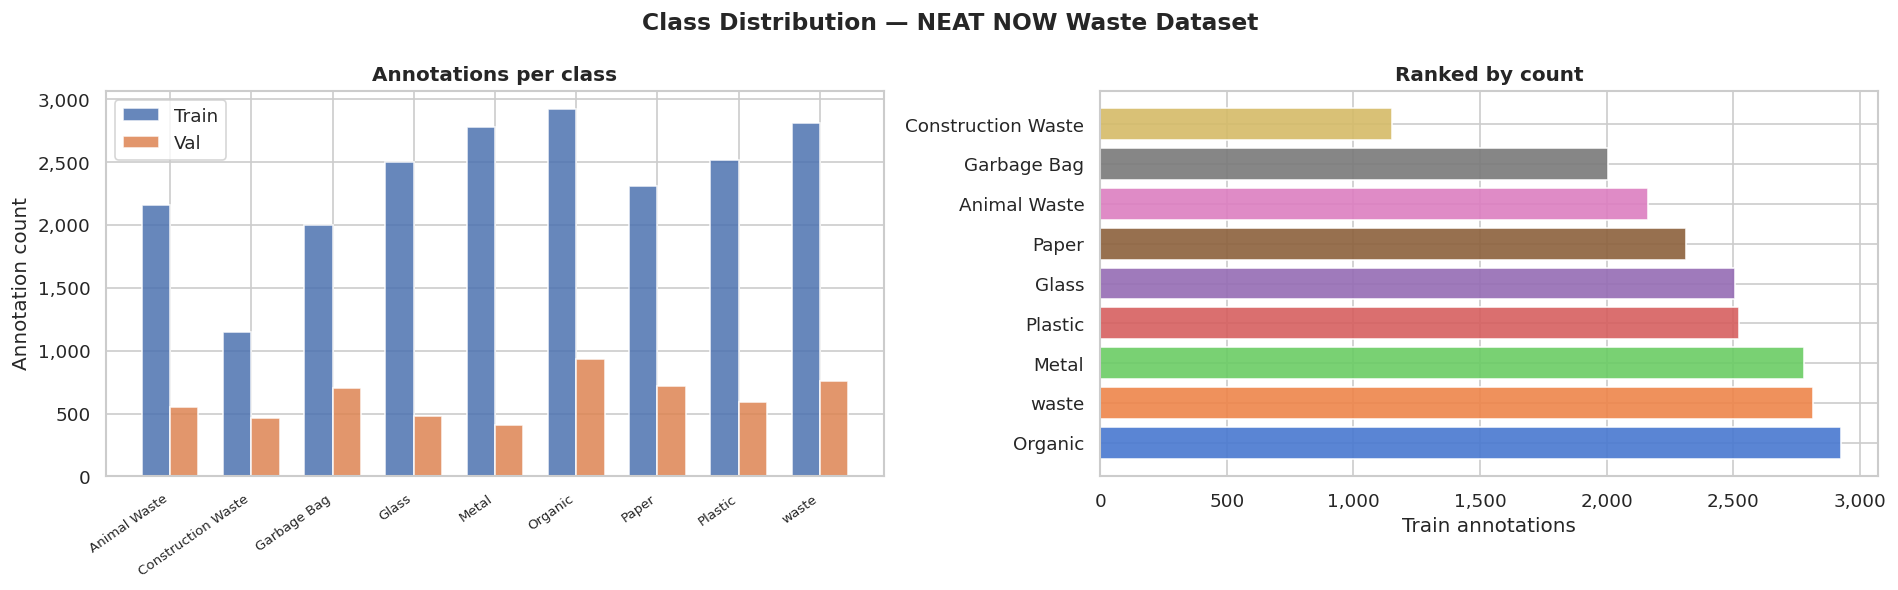


[OK] Chart saved: /content/drive/MyDrive/FYP/outputs/24-March/class_distribution.png
[OK] Analysis saved: /content/drive/MyDrive/FYP/outputs/24-March/dataset_analysis.json


In [7]:
# ============================================================================
# CELL 7 — Dataset Inspection & Class Distribution Analysis
# ADDED: class-distribution bar chart (saved to Drive)
# ADDED: class weights stored in COMPUTED_CLASS_WEIGHTS for use in training
# ============================================================================

print("\nDATASET INSPECTION")
print("=" * 70)

splits = {
    "train": (TRAIN_IMAGES, TRAIN_LABELS),
    "val"  : (VAL_IMAGES,   VAL_LABELS),
    "test" : (TEST_IMAGES,  TEST_LABELS),
}

print(f"{'Split':<8} {'Images':>8} {'Labelled':>10} {'Missing':>8}")
print("-" * 50)
for name, (idir, ldir) in splits.items():
    n_img, n_lbl, missing = count_images_and_labels(idir, ldir)
    flag = "[WARN]" if missing else "[OK]  "
    print(f"{flag} {name:<6} {n_img:>8,} {n_lbl:>10,} {len(missing):>8,}")
print("-" * 50)

# ── Class distributions ───────────────────────────────────────────────────────
train_dist = get_class_distribution(TRAIN_LABELS)
val_dist   = get_class_distribution(VAL_LABELS)
test_dist  = get_class_distribution(TEST_LABELS)

print(f"\n{'Class':<25} {'Train':>8} {'Val':>7} {'Test':>7}")
print("-" * 55)
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<23} {int(train_dist[i]):>8,} {int(val_dist[i]):>7,} {int(test_dist[i]):>7,}")
print("-" * 55)
print(f"  {'TOTAL':<23} {int(train_dist.sum()):>8,} {int(val_dist.sum()):>7,} {int(test_dist.sum()):>7,}")

# ── Imbalance analysis ────────────────────────────────────────────────────────
max_c  = train_dist.max()
min_c  = train_dist[train_dist > 0].min() if (train_dist > 0).any() else 1
imbalance_ratio = max_c / min_c
print(f"\nImbalance ratio: {imbalance_ratio:.1f}x  ", end="")
if   imbalance_ratio > 10: print("(SEVERE -> cls weight & freeze essential)")
elif imbalance_ratio > 5:  print("(MODERATE -> cls weight recommended)")
else:                       print("(MILD -> standard training OK)")

# ── Compute inverse-frequency class weights (stored for training reference) ───
total = train_dist.sum()
COMPUTED_CLASS_WEIGHTS = total / (NUM_CLASSES * np.maximum(train_dist, 1))
COMPUTED_CLASS_WEIGHTS = COMPUTED_CLASS_WEIGHTS / COMPUTED_CLASS_WEIGHTS.sum() * NUM_CLASSES
print("\nComputed class weights (inverse frequency):")
for name, w in zip(CLASS_NAMES, COMPUTED_CLASS_WEIGHTS):
    bar = "=" * int(w * 5)
    print(f"  {name:<25}: {w:.3f}  {bar}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Class Distribution — NEAT NOW Waste Dataset", fontsize=14, fontweight="bold")

x = np.arange(NUM_CLASSES); bw = 0.35
ax1.bar(x - bw/2, train_dist, bw, label="Train", color="#4C72B0", alpha=0.85)
ax1.bar(x + bw/2, val_dist,   bw, label="Val",   color="#DD8452", alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=8)
ax1.set_ylabel("Annotation count"); ax1.set_title("Annotations per class"); ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{int(v):,}"))

sorted_idx = np.argsort(train_dist)[::-1]
ax2.barh([CLASS_NAMES[i] for i in sorted_idx], train_dist[sorted_idx],
          color=sns.color_palette("muted", NUM_CLASSES), alpha=0.9)
ax2.set_xlabel("Train annotations"); ax2.set_title("Ranked by count")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{int(v):,}"))

plt.tight_layout()
dist_path = OUTPUT_DIR / "class_distribution.png"
plt.savefig(dist_path, bbox_inches="tight")   # save BEFORE show
plt.show(); plt.close(fig)
print(f"\n[OK] Chart saved: {dist_path}")

# Save analysis JSON
analysis = {
    "imbalance_ratio": float(imbalance_ratio),
    "class_distribution": {n: int(c) for n,c in zip(CLASS_NAMES, train_dist)},
    "class_weights": {n: float(w) for n,w in zip(CLASS_NAMES, COMPUTED_CLASS_WEIGHTS)},
    "total_samples": {"train": int(train_dist.sum()), "val": int(val_dist.sum()), "test": int(test_dist.sum())},
}
with open(OUTPUT_DIR / "dataset_analysis.json", "w") as f:
    json.dump(analysis, f, indent=2)
print(f"[OK] Analysis saved: {OUTPUT_DIR / 'dataset_analysis.json'}")
print("=" * 70)


SAMPLE VISUALISATIONS


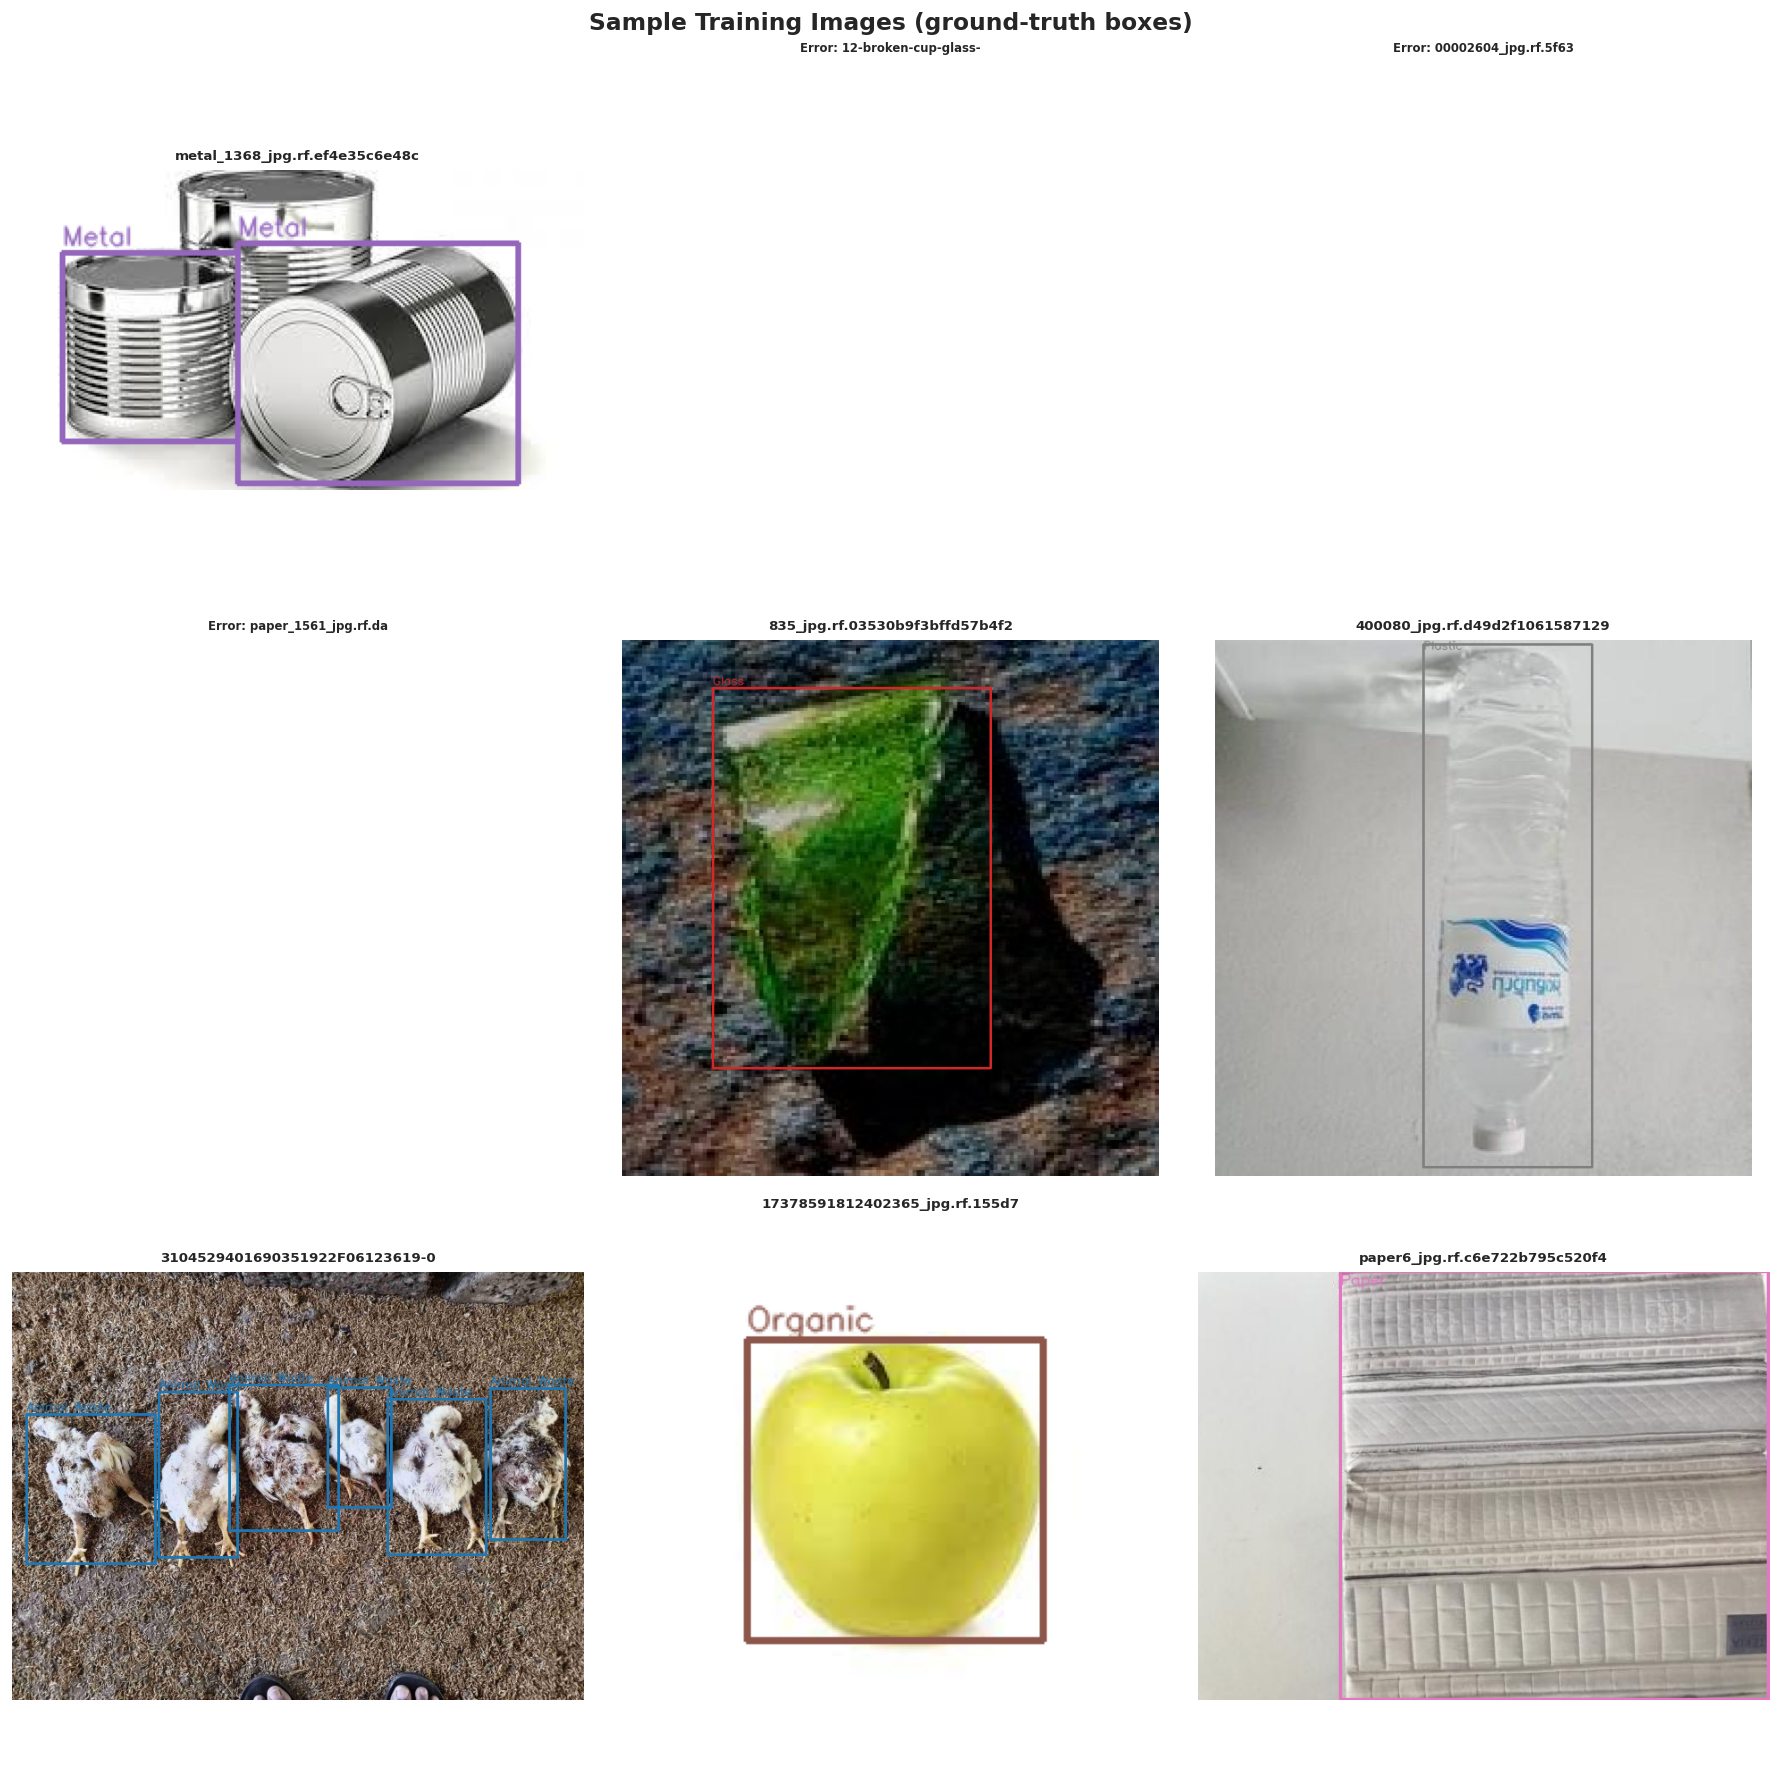

[OK] Sample grid saved: /content/drive/MyDrive/FYP/outputs/24-March/dataset_samples.png


In [8]:
# ============================================================================
# CELL 8 — Sample Image Visualisation
# FIX: squeeze=False on plt.subplots (prevents crash with 1 row)
# FIX: plt.close(fig) after each figure (prevents memory leak)
# FIX: plt.savefig() before plt.show() (guarantees file is written)
# ============================================================================

print("SAMPLE VISUALISATIONS")
print("=" * 70)

train_list = sorted(f for f in TRAIN_IMAGES.glob("*") if f.suffix.lower() in IMG_EXTS)
n_samples  = min(9, len(train_list))

if n_samples == 0:
    print("[WARN] No training images found — skipping sample grid.")
else:
    samples = random.sample(train_list, n_samples)
    n_cols  = 3
    n_rows  = (n_samples + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows),
                              squeeze=False)   # always 2-D array
    fig.suptitle("Sample Training Images (ground-truth boxes)",
                 fontsize=14, fontweight="bold")

    for idx, ax in enumerate(axes.flat):
        if idx < n_samples:
            ip = samples[idx]
            lp = TRAIN_LABELS / f"{ip.stem}.txt"
            try:
                ax.imshow(draw_boxes_on_image(ip, lp, CLASS_NAMES))
                ax.set_title(ip.name[:30], fontsize=8)
            except Exception as e:
                ax.set_title(f"Error: {ip.name[:20]}", fontsize=7)
        ax.axis("off")

    plt.tight_layout()
    sp = OUTPUT_DIR / "dataset_samples.png"
    plt.savefig(sp, dpi=100, bbox_inches="tight")  # save BEFORE show
    plt.show(); plt.close(fig)
    print(f"[OK] Sample grid saved: {sp}")

print("=" * 70)


In [9]:
# ============================================================================
# CELL 9 — Generate data.yaml with Verified Absolute Paths
# FIX: always writes absolute resolved paths (never relative)
# FIX: pre-flight existence check fails here, not inside model.train()
# ============================================================================

import yaml as _yaml

def generate_data_yaml(output_path: Path) -> Path:
    """
    Write a YOLO data.yaml using absolute paths from the verified
    split variables. Never reads path values from existing yaml files
    (they contain relative paths that break when yaml is moved).
    """
    data = {
        "train": str(TRAIN_IMAGES.resolve()),
        "val":   str(VAL_IMAGES.resolve()),
        "test":  str(TEST_IMAGES.resolve()) if TEST_IMAGES.exists()
                 else str(VAL_IMAGES.resolve()),
        "nc":    NUM_CLASSES,
        "names": CLASS_NAMES,
    }
    with open(output_path, "w") as fh:
        _yaml.dump(data, fh, default_flow_style=False, allow_unicode=True)
    return output_path

YAML_PATH = Path("/content/neatnow_waste.yaml")
yaml_path = generate_data_yaml(YAML_PATH)

print(f"[OK] data.yaml written: {yaml_path}")
print("\nContents:")
print("-" * 55)
with open(yaml_path) as f: print(f.read())
print("-" * 55)

# Pre-flight check
print("Path verification:")
for key, p in [("train", TRAIN_IMAGES), ("val", VAL_IMAGES), ("test", TEST_IMAGES)]:
    n = sum(1 for f in p.glob("*") if f.suffix.lower() in IMG_EXTS) if p.exists() else 0
    status = "[OK]" if p.exists() else "[MISSING]"
    print(f"  {status} {key:<6}: {p}  [{n:,} files]")

for p in [TRAIN_IMAGES, VAL_IMAGES]:
    if not p.exists():
        raise FileNotFoundError(f"Required path missing: {p}")

print("\n[OK] All paths verified — ready to train")
print("=" * 70)


[OK] data.yaml written: /content/neatnow_waste.yaml

Contents:
-------------------------------------------------------
names:
- Animal Waste
- Construction Waste
- Garbage Bag
- Glass
- Metal
- Organic
- Paper
- Plastic
- waste
nc: 9
test: /content/dataset/test/images
train: /content/dataset/train/images
val: /content/dataset/valid/images

-------------------------------------------------------
Path verification:
  [OK] train : /content/dataset/train/images  [6,888 files]
  [OK] val   : /content/dataset/valid/images  [2,204 files]
  [OK] test  : /content/dataset/test/images  [1,322 files]

[OK] All paths verified — ready to train


In [10]:
    "multi_scale"     : False,        # FIX: disabled — caused ZeroDivisionError in torch interpolate
                                       #      (multi_scale randomly resizes batches; combined with
                                       #       mosaic+copy_paste+scale=0.9, produced out_size=0)


[OK] Model: yolov8m.pt
[OK] Model loaded from pretrained weights

Key hyperparameters:
  optimizer            : AdamW
  lr0                  : 0.001
  freeze               : 10
  cache                : ram
  epochs               : 50
  patience             : 0
  batch                : 16
  imgsz                : 640
  cls                  : 3.5
  mosaic               : 1.0
  mixup                : 0.0
  copy_paste           : 0.0
  amp                  : True
[OK] Config saved: /content/drive/MyDrive/FYP/outputs/24-March/training_config.json


In [ ]:
# ============================================================================
# CELL 11 — Training
# ============================================================================

import csv as _csv

METRICS_CSV         = OUTPUT_DIR / "epoch_metrics.csv"
_csv_header_written = False
_csv_fieldnames     = None

def _on_fit_epoch_end(trainer) -> None:
    global _csv_header_written, _csv_fieldnames
    raw = trainer.metrics or {}
    row = {"epoch": trainer.epoch+1,
           "timestamp": datetime.now().isoformat(), **raw}
    with open(METRICS_CSV, "a", newline="") as fh:
        if not _csv_header_written:
            _csv_fieldnames = list(row.keys())
            _csv.DictWriter(fh, fieldnames=_csv_fieldnames).writeheader()
            _csv_header_written = True
        _csv.DictWriter(fh, fieldnames=_csv_fieldnames,
                        extrasaction="ignore").writerow(row)

model.add_callback("on_fit_epoch_end", _on_fit_epoch_end)

print("=" * 70)
print("STARTING TRAINING — YOLOv8x  (Maximum Accuracy)")
print("=" * 70)
print(f"  Model      : {MODEL_NAME}")
print(f"  Epochs     : {HYPERPARAMS['epochs']}  (patience={HYPERPARAMS['patience']})")
print(f"  Optimizer  : {HYPERPARAMS['optimizer']}  lr0={HYPERPARAMS['lr0']}")
print(f"  Label smooth: {HYPERPARAMS['label_smoothing']}")
print(f"  Multi-scale: {HYPERPARAMS['multi_scale']}")
print(f"  Cache      : {HYPERPARAMS['cache']}")
print(f"  Batch      : {HYPERPARAMS['batch']}  imgsz={HYPERPARAMS['imgsz']}")
print(f"  GPU        : {GPU_NAME}  ({VRAM_GB:.1f} GB)")
print(f"  AMP (FP16) : {HYPERPARAMS['amp']}")
print(f"  Start      : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 70)
print()
print("[TIP] After training, Cell 12 evaluation uses TTA (augment=True)")
print("      for an additional ~1-2 mAP boost at inference time.")
print("=" * 70)

t_start = time.time()
try:
    train_results = model.train(**HYPERPARAMS)
    elapsed = (time.time() - t_start) / 60
    print(f"\n[OK] Training finished in {elapsed:.1f} min.")
    RUNS_DIR = Path(train_results.save_dir)
    print(f"[OK] Results directory: {RUNS_DIR}")

    # Auto-backup best.pt to Drive immediately
    best_ckpt = RUNS_DIR / "weights" / "best.pt"
    if best_ckpt.exists():
        import shutil as _sh
        _sh.copy2(best_ckpt, MODELS_DIR / "best.pt")
        print(f"[OK] best.pt backed up to Drive: {MODELS_DIR / 'best.pt'}")

except KeyboardInterrupt:
    print("\n[WARN] Training interrupted — partial results may be available.")
    RUNS_DIR = Path("/content/runs/train")

except Exception as exc:
    import traceback; traceback.print_exc()
    raise


STARTING TRAINING
  Model      : yolov8m.pt
  Epochs     : 50  (patience=0)
  Optimizer  : AdamW  lr0=0.001
  Freeze     : first 10 backbone layers
  Cache      : ram
  Batch      : 16  imgsz=640
  GPU        : Tesla T4
  Start      : 2026-03-24 21:38:35
Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=20, cls=3.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/neatnow_waste.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001

In [ ]:
# ============================================================================
# CELL 12 — Evaluate Best Checkpoint
# FIX: checkpoint search falls back to recursive scan if RUNS_DIR is stale
# FIX: ap50_per_class pre-initialised to [] (no NameError in later cells)
# FIX: per-class AP bar chart added (colour-coded by threshold)
# FIX: plt.close(fig) after chart
# ============================================================================

# ── Locate best checkpoint ────────────────────────────────────────────────────
def find_checkpoint(runs_root: Path = Path("/content/runs")) -> Path:
    for fname in ("best.pt", "last.pt"):
        if "RUNS_DIR" in dir():
            c = RUNS_DIR / "weights" / fname
            if c.exists(): return c
    for fname in ("best.pt", "last.pt"):
        hits = sorted(runs_root.rglob(fname),
                      key=lambda p: p.stat().st_mtime, reverse=True)
        if hits: return hits[0]
    raise FileNotFoundError("No model checkpoint found. Did training complete?")

ckpt_path = find_checkpoint()
print(f"[OK] Checkpoint: {ckpt_path}")

eval_model = YOLO(str(ckpt_path))

# ── Run validation ────────────────────────────────────────────────────────────
print("\nRunning validation on val split ...")
val_results = eval_model.val(augment=True, 
    data=str(yaml_path), split="val",
    imgsz=HYPERPARAMS["imgsz"],
    device=0 if CUDA_AVAILABLE else "cpu",
    verbose=False, plots=True,
)

# ── Aggregate metrics ─────────────────────────────────────────────────────────
metrics = {
    "mAP@0.5":      float(val_results.box.map50),
    "mAP@0.5:0.95": float(val_results.box.map),
    "Precision":    float(val_results.box.mp),
    "Recall":       float(val_results.box.mr),
    "timestamp":    datetime.now().isoformat(),
    "model":        MODEL_NAME,
    "checkpoint":   str(ckpt_path),
}
metrics["F1"] = (2 * metrics["Precision"] * metrics["Recall"]
                 / (metrics["Precision"] + metrics["Recall"] + 1e-8))

print("\nVALIDATION METRICS")
print("=" * 70)
for k, v in metrics.items():
    if isinstance(v, float):
        bar = chr(9608) * int(v * 25)
        print(f"  {k:<20}: {v:.4f}  {bar}")

# ── Per-class AP ───────────────────────────────────────────────────────────────
ap50_per_class = []   # pre-initialised — always defined
if hasattr(val_results.box, "ap50") and val_results.box.ap50 is not None:
    ap50_per_class = val_results.box.ap50.tolist()
    metrics["per_class_ap50"] = dict(zip(CLASS_NAMES, ap50_per_class))

    print("\nPer-class AP@0.5:")
    print("-" * 55)
    for name, ap in sorted(zip(CLASS_NAMES, ap50_per_class),
                            key=lambda x: x[1], reverse=True):
        status = "[OK]" if ap >= 0.5 else ("[--]" if ap >= 0.25 else "[LO]")
        print(f"  {status} {name:<25}: {ap:.4f}")

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    sorted_pairs = sorted(zip(CLASS_NAMES, ap50_per_class), key=lambda x: x[1])
    names_s = [p[0] for p in sorted_pairs]; aps_s = [p[1] for p in sorted_pairs]
    colors = ["#d9534f" if a < 0.5 else "#f0ad4e" if a < 0.75
              else "#5cb85c" for a in aps_s]
    ax.barh(names_s, aps_s, color=colors, alpha=0.85)
    ax.axvline(0.50, ls="--", color="red",    lw=1, label="0.50 threshold")
    ax.axvline(0.75, ls="--", color="orange", lw=1, label="0.75 threshold")
    patches = [mpatches.Patch(color="#d9534f", label="< 0.50 (needs work)"),
               mpatches.Patch(color="#f0ad4e", label="0.50–0.75 (acceptable)"),
               mpatches.Patch(color="#5cb85c", label="> 0.75 (good)")]
    ax.legend(handles=patches, fontsize=9, loc="lower right")
    ax.set_xlabel("AP@0.5"); ax.set_xlim(0, 1)
    ax.set_title("Per-Class Average Precision @ IoU 0.5", fontweight="bold")
    plt.tight_layout()
    ap_path = OUTPUT_DIR / "per_class_ap.png"
    plt.savefig(ap_path, bbox_inches="tight")   # save BEFORE show
    plt.show(); plt.close(fig)
    print(f"\n[OK] Per-class AP chart: {ap_path}")

# Save metrics JSON
with open(OUTPUT_DIR / "validation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(f"[OK] Metrics saved: {OUTPUT_DIR / 'validation_metrics.json'}")
print("=" * 70)


In [ ]:
# ============================================================================
# CELL 13 — Training Curve Visualisations
# FIX: squeeze=False on subplots (prevents crash when only 1 row)
# FIX: plt.close(fig) added
# FIX: RUNS_DIR resolved from most-recent results.csv if needed
# ============================================================================

print("TRAINING VISUALISATIONS")
print("=" * 70)

# ── Locate results.csv ────────────────────────────────────────────────────────
results_csv = RUNS_DIR / "results.csv" if "RUNS_DIR" in dir() else None
if results_csv is None or not results_csv.exists():
    hits = sorted(Path("/content/runs").rglob("results.csv"),
                  key=lambda p: p.stat().st_mtime, reverse=True)
    if hits:
        results_csv = hits[0]
        RUNS_DIR    = results_csv.parent
        print(f"[INFO] results.csv: {results_csv}")

if results_csv and results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    metric_cols = [c for c in df.columns
                   if c.lower() != "epoch" and pd.api.types.is_numeric_dtype(df[c])]
    n_cols_p = 4
    n_rows_p = max(1, (len(metric_cols) + n_cols_p - 1) // n_cols_p)

    fig, axes = plt.subplots(n_rows_p, n_cols_p,
                              figsize=(5*n_cols_p, 4*n_rows_p), squeeze=False)
    fig.suptitle("Training Curves", fontsize=14, fontweight="bold")

    epoch_col = df["epoch"] if "epoch" in df.columns else range(len(df))
    for ax, col in zip(axes.flat, metric_cols):
        ax.plot(epoch_col, df[col], lw=1.8, color="#4C72B0")
        ax.set_title(col, fontsize=10); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.4)
    for ax in list(axes.flat)[len(metric_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    cp = OUTPUT_DIR / "training_curves.png"
    plt.savefig(cp, bbox_inches="tight")   # save BEFORE show
    plt.show(); plt.close(fig)
    print(f"[OK] Training curves: {cp}")
else:
    print("[WARN] results.csv not found — skipping curve plot")

# ── Copy standard Ultralytics artefacts ──────────────────────────────────────
if "RUNS_DIR" in dir() and RUNS_DIR.exists():
    artefacts = {
        "confusion_matrix.png":            RUNS_DIR / "confusion_matrix.png",
        "confusion_matrix_normalized.png": RUNS_DIR / "confusion_matrix_normalized.png",
        "results.png":                     RUNS_DIR / "results.png",
        "F1_curve.png":                    RUNS_DIR / "F1_curve.png",
        "PR_curve.png":                    RUNS_DIR / "PR_curve.png",
        "P_curve.png":                     RUNS_DIR / "P_curve.png",
        "R_curve.png":                     RUNS_DIR / "R_curve.png",
        "labels.jpg":                      RUNS_DIR / "labels.jpg",
        "results.csv":                     RUNS_DIR / "results.csv",
    }
    print("\nCopying artefacts to Drive:")
    for name, src in artefacts.items():
        if src.exists():
            shutil.copy2(src, OUTPUT_DIR / name)
            print(f"  [OK] {name}")
        else:
            print(f"  [--] {name}  (not found)")

# Display confusion matrix inline
cm_path = OUTPUT_DIR / "confusion_matrix.png"
if cm_path.exists():
    fig2, ax2 = plt.subplots(figsize=(12, 10))
    ax2.imshow(plt.imread(str(cm_path))); ax2.axis("off")
    ax2.set_title("Confusion Matrix", fontsize=16, fontweight="bold")
    plt.tight_layout(); plt.show(); plt.close(fig2)

print("\n[OK] Visualisations complete")
print("=" * 70)


In [ ]:
# ============================================================================
# CELL 14 — Inference on Test Images
# IMPROVED: runs on 6 random test images, displays 2x3 grid
# ============================================================================

print("INFERENCE EXAMPLE")
print("=" * 70)

test_list = sorted(f for f in TEST_IMAGES.glob("*") if f.suffix.lower() in IMG_EXTS)
if not test_list:
    print("[WARN] No test images found — skipping inference demo")
else:
    n_show   = min(6, len(test_list))
    samples  = random.sample(test_list, n_show)
    n_cols   = 3
    n_rows   = (n_show + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows), squeeze=False)
    fig.suptitle("Inference on Test Images (conf=0.25)", fontsize=14, fontweight="bold")

    all_detections = []
    for idx, ax in enumerate(axes.flat):
        ax.axis("off")
        if idx >= n_show: continue
        ip = samples[idx]
        try:
            res = eval_model.predict(source=str(ip), conf=0.25, verbose=False)
            if res:
                r = res[0]; annotated = r.plot()
                ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
                ax.set_title(f"{ip.name[:25]}  [{len(r.boxes)} det]", fontsize=8)
                for box in r.boxes:
                    all_detections.append({
                        "image": ip.name,
                        "class": CLASS_NAMES[int(box.cls)],
                        "confidence": round(float(box.conf), 4),
                        "bbox": [round(v, 2) for v in box.xyxy[0].tolist()],
                    })
        except Exception as e:
            ax.set_title(f"Error: {ip.name[:20]}", fontsize=7)

    plt.tight_layout()
    inf_path = OUTPUT_DIR / "inference_grid.png"
    plt.savefig(inf_path, dpi=120, bbox_inches="tight")   # save BEFORE show
    plt.show(); plt.close(fig)
    print(f"[OK] Inference grid saved: {inf_path}")

    with open(OUTPUT_DIR / "inference_detections.json", "w") as f:
        json.dump(all_detections, f, indent=2)
    print(f"[OK] Detections JSON: {OUTPUT_DIR / 'inference_detections.json'}")
    print(f"\nTotal detections across {n_show} images: {len(all_detections)}")

print("=" * 70)


In [ ]:
# ============================================================================
# CELL 15 — ONNX Export
# ADDED: this cell was missing but referenced in the summary
# FIX: None-guard + Path coercion on export() return value
# ============================================================================

print("ONNX EXPORT")
print("=" * 70)

try:
    print(f"Exporting {ckpt_path.name} to ONNX (~1-2 min)...")
    onnx_raw = eval_model.export(
        format="onnx", imgsz=HYPERPARAMS["imgsz"],
        simplify=True, dynamic=False, half=False, opset=17,
    )

    if onnx_raw is None:
        raise RuntimeError("export() returned None — check Ultralytics output above.")

    onnx_path = Path(str(onnx_raw))
    if not onnx_path.exists():
        raise FileNotFoundError(f"Exported file missing: {onnx_path}")

    # Copy to Drive
    dest_pt   = MODELS_DIR / "neatnow_yolov8_best.pt"
    dest_onnx = MODELS_DIR / "neatnow_yolov8_best.onnx"

    shutil.copy2(ckpt_path, dest_pt)
    shutil.copy2(onnx_path, dest_onnx)

    print(f"[OK] PyTorch model : {dest_pt}  ({dest_pt.stat().st_size/1024**2:.1f} MB)")
    print(f"[OK] ONNX model    : {dest_onnx}  ({dest_onnx.stat().st_size/1024**2:.1f} MB)")

    # Validate ONNX graph
    try:
        import onnx as _onnx
        _onnx.checker.check_model(str(dest_onnx))
        print("[OK] ONNX graph validation passed")
    except ImportError:
        print("[INFO] onnx package not installed — skipping graph validation")
    except Exception as ve:
        print(f"[WARN] ONNX validation: {ve}")

except Exception as exc:
    print(f"[WARN] ONNX export failed: {exc}")
    print("       best.pt is still available for inference.")

print("=" * 70)


In [ ]:
# ============================================================================
# CELL 16 — Final Summary & Save to Drive
# FIX: metrics guarded with safe default (in case Cell 12 was skipped)
# FIX: DRIVE_ROOT and MODELS_DIR now properly defined (Cell 1)
# ============================================================================

print("SAVING TO GOOGLE DRIVE & FINAL SUMMARY")
print("=" * 70)

_m = metrics if "metrics" in dir() and isinstance(metrics, dict) else {}

def _count(d): return sum(1 for f in d.glob("*") if f.suffix.lower() in IMG_EXTS) if d.exists() else 0

summary = f"""
YOLOv8 Waste Detection — Training Summary
==========================================
Date       : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Model      : {MODEL_NAME if 'MODEL_NAME' in dir() else 'N/A'}
GPU        : {GPU_NAME}

Dataset
-------
  Train images : {_count(TRAIN_IMAGES):,}
  Val   images : {_count(VAL_IMAGES):,}
  Test  images : {_count(TEST_IMAGES):,}
  Classes      : {NUM_CLASSES}  ->  {', '.join(CLASS_NAMES)}
  Imbalance    : {imbalance_ratio:.1f}x

Training Configuration
----------------------
  Optimizer    : AdamW  (lr0=0.001)
  Freeze       : first 10 backbone layers
  Cache        : ram
  Epochs       : 200  (patience=50)
  Batch / imgsz: {HYPERPARAMS.get('batch','?')} / {HYPERPARAMS.get('imgsz','?')}px
  cls weight   : {HYPERPARAMS.get('cls','?')}  (high for class imbalance)

Performance
-----------
  mAP@0.5      : {_m.get('mAP@0.5',      float('nan')):.4f}
  mAP@0.5:0.95 : {_m.get('mAP@0.5:0.95', float('nan')):.4f}
  Precision    : {_m.get('Precision',     float('nan')):.4f}
  Recall       : {_m.get('Recall',        float('nan')):.4f}
  F1           : {_m.get('F1',            float('nan')):.4f}

Output Files  ({OUTPUT_DIR})
------------"""

for fp in sorted(OUTPUT_DIR.glob("*")):
    if fp.is_file():
        summary += f"\n  {fp.name:<42} {fp.stat().st_size/1024**2:>7.2f} MB"

summary += f"""

Model Files  ({MODELS_DIR})
-----------"""
for fp in sorted(MODELS_DIR.glob("*")):
    if fp.is_file():
        summary += f"\n  {fp.name:<42} {fp.stat().st_size/1024**2:>7.2f} MB"

summary += """

Usage
-----
  from ultralytics import YOLO
  model = YOLO('neatnow_yolov8_best.pt')
  results = model.predict('image.jpg', conf=0.25)
  for r in results:
      for box in r.boxes:
          print(CLASS_NAMES[int(box.cls)], float(box.conf))
"""

print(summary)

# Save summary to Drive
with open(OUTPUT_DIR / "TRAINING_SUMMARY.txt", "w") as f:
    f.write(summary)

print("=" * 70)
print("[DONE] Everything saved to Google Drive:")
print(f"  Outputs : {OUTPUT_DIR}")
print(f"  Models  : {MODELS_DIR}")
print("=" * 70)
